# Model Evaluation and Improvement

- Focus of the chapter is on supervised learning.
- Basic evaluation of supervised models:
  - Split data to training and test sets
  - Fit the model on training set
  - Use the `score` method to evaluate on the test set. For classification, the score is the fraction of correctly classified samples. For regression, the score is the coefficient of determination $R^2$

In [1]:
# Standard imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mglearn

%matplotlib inline

In [2]:
# Example of evaluating a classification model using the score method
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

regressor = LogisticRegression()

# Create synthetic data set
X, y = make_blobs(random_state=0, centers=2)
X_train, X_test, y_train, y_test = train_test_split(X, y) # split data to training and test sets

# Fit model on training set
regressor.fit(X_train, y_train)

# Determine the score using the `score` method
print('Test score: {:.2f}'.format(regressor.score(X_test, y_test)))

Test score: 0.96


Topics to discuss in the chapter:
- **Cross validation.** a more robust way to assess generalization performance
- Methods of performance evaluation other than `score()`
- **Grid search** for hyperparameter tuning


## Cross-Validation

The most commonly used type is **$k$-fold cross validation**.

### $k$-Fold Cross Validation
1. Data is divided into $k$ folds
2. fold $2$ to fold $k$ will be used as training set and fold $1$ will be used as test set
3. Test score is computed for fold $1$
4. Repeat steps 2 to 3 for each fold

In [3]:
# Example of using k-fold cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# Instantiate logistic regression model
regressor = LogisticRegression(max_iter=200)

# Load data set
iris = load_iris()
X = iris.data
y = iris.target

# Five-fold cross validation
scores = cross_val_score(regressor, X, y)

# Print scores
print('Cross validation scores:')
for i, score in enumerate(scores):
    print(f' Fold {i}: {score:.3f}')
print('------------------------')
print(' Average score: {:.3f}'.format(scores.mean()))

Cross validation scores:
 Fold 0: 0.967
 Fold 1: 1.000
 Fold 2: 0.933
 Fold 3: 0.967
 Fold 4: 1.000
------------------------
 Average score: 0.973


### Benefits of Cross-Validation
- Each sample is in the test set exactly once. So, how well the model generalizes is tested on all of the samples. On the other hand, `train_test_split` randomly splits the data, and the performance of the model may depend on the chance of getting "easy" test samples.
- It provides information on how sensitive a model is to the choice of training set.
- We utilize the data set more effectively, particularly for small datasets.

The main disadvantage is the increased computational cost: with $k$-fold cross-validation, we're now training and testing $k$ models.

**Important:** Cross-validation *does not* return a model. Its only purpose is to check how well an algorithm generalizes to a specific dataset.

### Stratified k-Fold Cross-Validation and Other Strategies

For classification tasks, it's not really a good idea to use standard cross-validation -- splitting the dataset into consecutive folds. This is true especially for sorted class labels.

In [4]:
print('Target variable of the Iris Data Set:\n', y)
print('\nSample count for each label:')
value_counts = np.unique_counts(y)
for label, count in zip(value_counts.values,value_counts.counts):
    print(f' label {label}: {count}')

Target variable of the Iris Data Set:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]

Sample count for each label:
 label 0: 50
 label 1: 50
 label 2: 50


For the Iris data set, if we do a standard 3-fold cross validation, the folds will be as follows:
- Fold 1: First 50 samples, all samples have labels 0, the training set contains samples only with labels 1 or 2.
- Fold 2: Second 50 samples, all samples have labels 1, the training set contains samples only with labels 0 or 2.
- Fold 3: Last 50 samples, all have labels 2, training set contains samples only with labels 0 or 1.

In each fold, the model would learn only the two labels in the training set, and will be tested on samples with a label different from the training. So, the result will be a score of zero!

In [5]:
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

rng = np.random.RandomState(1338)
cmap_data = plt.cm.winter
cmap_group = plt.cm.Spectral
cmap_cv = plt.cm.gray_r

def plot_cv_indices(cv, X, y, ax, n_splits, group=None, lw=10):
    """Create a sample plot for indices of a cross-validation object."""
    n_samples = X.shape[0]
    use_groups = "Group" in type(cv).__name__
    groups = group if use_groups else None
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=groups)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=lw,
            cmap=cmap_cv,
            vmin=-0.2,
            vmax=1.2,
        )

    # Plot of classes and group
    ax.scatter(
        range(len(X)),
        [ii + 1.5] * len(X),
        c=y,
        marker='_',
        lw=lw,
        cmap=cmap_data,
    )

    if group is not None:
        ax.scatter(
            range(len(X)),
            [ii + 2.5] * len(X),
            c=group,
            marker='_',
            lw=lw,
            cmap=cmap_group
        )

    # Add legend only for training set and test set
    norm = Normalize(vmin=-0.2, vmax=1.2)
    train_color = cmap_cv(norm(0))
    test_color = cmap_cv(norm(1))
    labels = np.unique(y)
    
    legend_elements = [
        Line2D(
            [0], [0],
            marker="_",
            color=train_color,
            markersize=20,
            linewidth=0,
            markeredgewidth=8,
            label="Training",
        ),
        Line2D(
            [0], [0],
            marker="_",
            color=test_color,
            markersize=20,
            linewidth=0,
            markeredgewidth=8,
            label="Test",
        ),
    ]
    
    ax.legend(handles=legend_elements, bbox_to_anchor=(1,1))
    
    # Formatting
    if group is not None:
        other_plots = ['class', 'group']
    else:
        other_plots = ['class']
        
    yticklabels = list(range(n_splits)) + other_plots
    ax.set(
        yticks=np.arange(n_splits + len(other_plots)) + 0.5,
        yticklabels=yticklabels,
        xlabel="Sample index",
        ylabel="CV iteration",
        ylim=[n_splits + len(other_plots) + 0.2, -0.2],
        xlim=[0, n_samples],
    )
    ax.set_title("{}".format(type(cv).__name__), fontsize=15)
    return ax

Standard 3-fold cross val scores:
 fold 1: 0.000
 fold 2: 0.000
 fold 3: 0.000


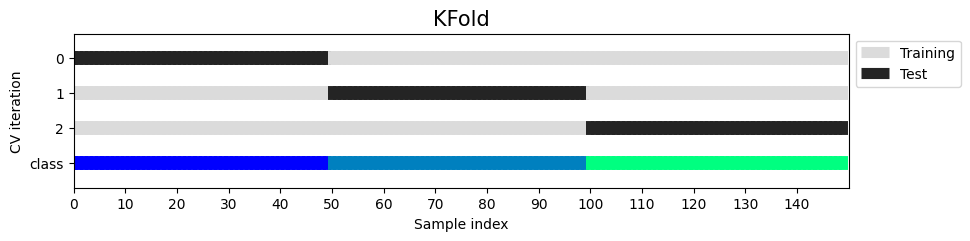

In [6]:
# Demonstration: Standard 3-fold classification on Iris dataset
from sklearn.model_selection import KFold

regressor = LogisticRegression(max_iter=200)
kfold = KFold(n_splits=3)
scores = cross_val_score(regressor, X, y, cv=kfold)

print('Standard 3-fold cross val scores:')
for i, score in enumerate(scores):
    print(f' fold {i+1}: {score:.3f}')


# Visualize split
fig,ax = plt.subplots(figsize=(10,2))
plot_cv_indices(kfold, X, y, ax, n_splits=3)
ax.set_xticks(np.arange(0,X.shape[0],10));

Instead of splitting data into consecutive folds for cross-validation, another way is to split so that the proportion between the labels is the same for each fold as they are in the whole data set. Cross-validation that implements this method of splitting is called **Stratified $k$-fold cross-validation**

For instance, for a data set with 2 classes, if 90% of the samples belong to the first class and 10% belong to the second, then, in each fold, 90% of the samples in the fold are from the first class, and 10% of the samples in the fold belong to the second. 

The proportion between classes in the whole data set is preserved in each fold.

For classification tasks, Scikit-learn's `cross_val_score` implements stratified cross-validation by default.

Stratified 3-fold cross val scores:
 Fold 0: 0.98
 Fold 1: 0.96
 Fold 2: 0.98


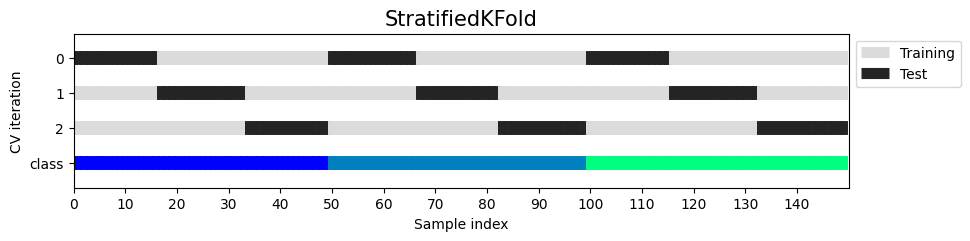

In [7]:
# Demonstration: Stratified k-fold cross validation on the Iris data set
from sklearn.model_selection import StratifiedKFold
stratified = StratifiedKFold(n_splits=3)
scores = cross_val_score(regressor, X, y, cv=stratified)
print('Stratified 3-fold cross val scores:')
for i, score in enumerate(scores):
    print(f' Fold {i}: {score}')

fig, ax = plt.subplots(figsize=(10,2))
plot_cv_indices(stratified, X, y, ax, 3)
ax.set_xticks(np.arange(0,X.shape[0],10));

#### Leave-one-out cross-validation

Another frequently used cross-validation method is **Leave-one-out**. This can be thought of as a $k$-fold cross-validation where each fold contains only one sample.

The training set in each iteration is the entire data set with one sample left out. The model is then tested on the sample that was left out.

There will be as much folds as there are samples. So, this method is more time-consuming especially for large datasets.

In [8]:
# Demonstration: Leave-one-out cross validation
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(regressor, X, y, cv=loo)
print('Leave-one-out cross val score:')
print('  Number of iterations:', len(scores))
print('  Mean score: {:.3f}'.format(scores.mean()))

Leave-one-out cross val score:
  Number of iterations: 150
  Mean score: 0.967


#### Shuffle-split cross-validation

Another flexible strategy for cross-validation is **shuffle-split**.

Here, we specify the training size `train_size`, the test size `test_size`, and how many iterations/splits on the data `n_splits`. In each split, we take a random sample of `train_size` many points from the data set, and take another random sample for the test set (`test_size` many points) from the remaining points in the data set.

Shuffle-split cross val scores:
 Split 1: 0.933
 Split 2: 0.933
 Split 3: 0.987
 Split 4: 0.947
 Split 5: 0.960
 Split 6: 0.947
 Split 7: 0.973
 Split 8: 1.000
 Split 9: 0.960
 Split 10: 0.987


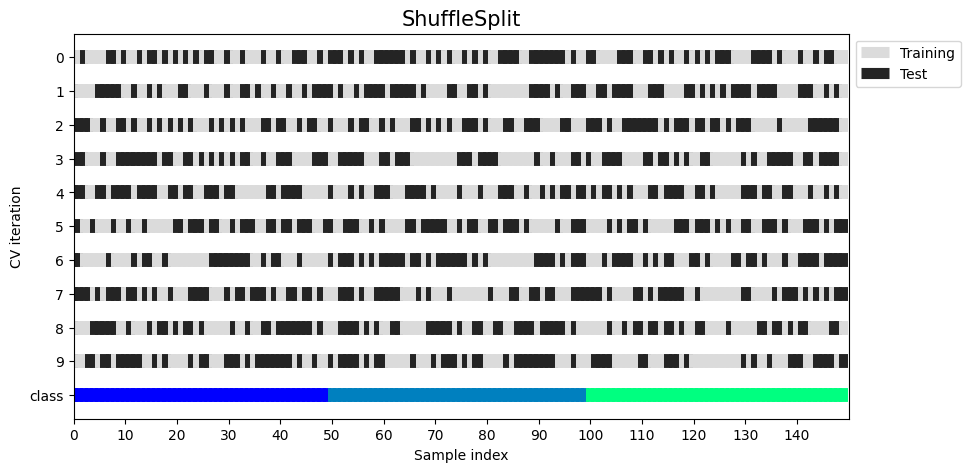

In [9]:
# Demonstration shuffle-split cross validation on the Iris data set
from sklearn.model_selection import ShuffleSplit

# To split the data set into 50% training set and 50% test set
# There are many ways to split the data 50-50. A consecutive split is a basic example (first 50% and last 50%)
# But the training set and test set need not be connected!
# Each subset can be generated by randomly picking out samples one-by-one until you get 50% of the total.
# Here only 10 of the possible ways to split the data 50-50 are considered

shuffle = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10, random_state=0)

scores = cross_val_score(regressor, X, y, cv=shuffle)
print('Shuffle-split cross val scores:')
for i, score in enumerate(scores):
    print(f' Split {i+1}: {score:.3f}')

# Visualize
fig, ax = plt.subplots(figsize=(10,5))
plot_cv_indices(shuffle, X, y, ax, 10)
ax.set_xticks(np.arange(0,X.shape[0],10));

#### Cross-validation with groups

There are times where it is best to group the data prior to cross-validation so that samples of the same group are not split when generating the training and test sets in each CV iteration.

The groups are not to be confused with the labels!

Examples:
- The task is to identify emotions; the samples of the data set are pictures of 100 people, each of which appear in multiple samples. A stratified k-fold strategy could be used, but it is likely that images of the same person appear in both the training and test set. In that case, the classifier would have an easier time in detecting emotions. This is not ideal because we want to assess how good the classifier is in detecting emotions of new faces. So, we can group the image samples by person first so that they are not split when generating the training and test sets (here, labels = emotions, groups = people)

- Grouping is common in medical applications where multiple samples come from a single patient but we want the model to generalize to new patients.

- Speech recognition where there are multiple recordings of the same speaker, but we are interested in recognizing speech of new speakers.

GroupKFold cross val scores:
 Fold 0: 0.947
 Fold 1: 1.000
 Fold 2: 0.324


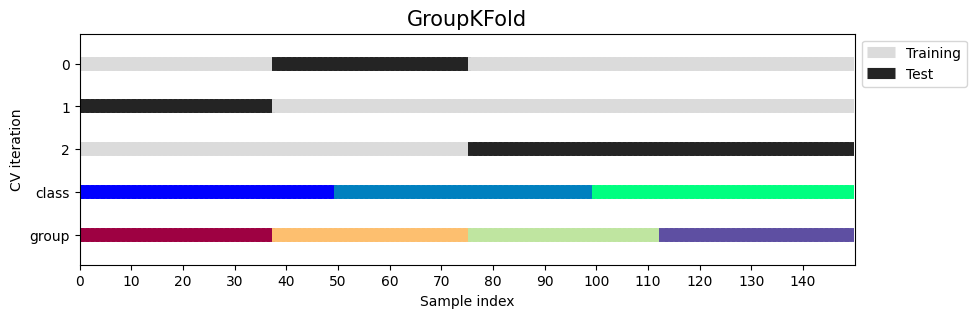

In [10]:
# Demonstration: cross val with groups
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(n_splits=3)

# For demonstration purposes the iris data set will be grouped randomly
# Here we'll explicitly define the group for each sample
# First 38 samples are in group 0, second 38 samples are in group 1, and so on...
rng = np.random.default_rng()
group = np.hstack([
    np.full(38,0,dtype=int),
    np.full(38,1,dtype=int),
    np.full(37,2,dtype=int),
    np.full(37,3,dtype=int)
])

scores = cross_val_score(regressor, X, y, groups=group, cv=group_kfold)
print('GroupKFold cross val scores:')
for i, score in enumerate(scores):
    print(f' Fold {i}: {score:.3f}')

fig,ax = plt.subplots(figsize=(10,3))
plot_cv_indices(group_kfold, X, y, ax, n_splits=3, group=group)
ax.set_xticks(np.arange(0,len(X),10));

A better strategy for cross-validation with groups is the `StratifiedGroupKFold` where we'll attempt to preserve the proportion between the classes in the whole dataset in each CV iteration (stratified folds) while ensuring that the restriction of non-overlapping groups holds.

Stratified group cross val scores:
 Fold 0: 0.960
 Fold 1: 0.757
 Fold 2: 0.947


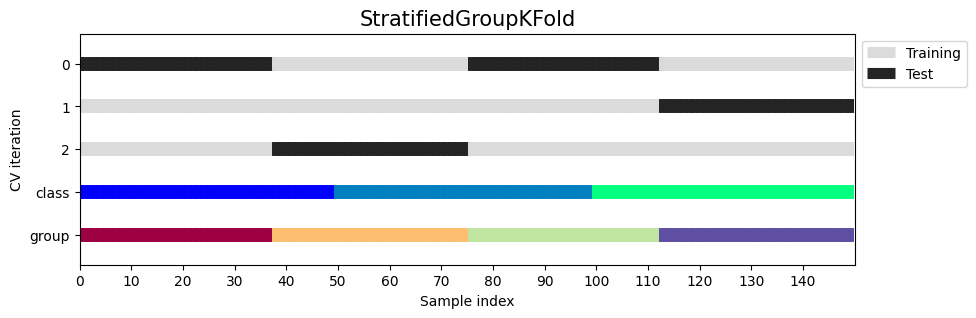

In [11]:
from sklearn.model_selection import StratifiedGroupKFold

group_stratified = StratifiedGroupKFold(n_splits=3)
scores = cross_val_score(regressor, X, y, groups=group, cv=group_stratified)
print("Stratified group cross val scores:")
for i, score in enumerate(scores):
    print(f' Fold {i}: {score:.3f}')

fig, ax = plt.subplots(figsize=(10,3))
plot_cv_indices(group_stratified, X, y, ax, n_splits=3, group=group)
ax.set_xticks(np.arange(0,len(X),10));

## Grid Search

We now have a way to evaluate how a model generalizes.

This section is about improving the model's generalization performance by tuning the model's parameters.

The most commonly used method for tuning model parameters is **grid search**, which essentially means trying out all possible combinations of the parameters.

**Example.** The support vector classifier has `gamma` and `C` as two of its main parameters. `gamma` is the kernel bandwidth and `C` is the regularization parameter that controls how strict the margins should be. We consider the following values for each parameter
| `C` | `gamma` |
| --- | --- |
| 0.001 | 0.001 |
| 0.01 | 0.01 |
| 0.1 | 0.1 |
| 1 | 1 |
| 10 | 10 |
| 100 | 100 |

and build an SVM model for each combination of `C` and `gamma`. This creates a grid of parameter settings for the SVM:
| | C=0.001 | C=0.01 |...| C=100|
|---|---|---|---|---|
|**gamma=0.001**|SVC(C=0.001,gamma=0.001)|SVC(C=0.01,gamma=0.001)|...|SVC(C=100,gamma=0.001)|
|**gamma=0.01**|SVC(C=0.001,gamma=0.01)|SVC(C=0.01,gamma=0.01)|...|SVC(C=100,gamma=0.01)|
|...|...|...|...|...|
|**gamma=100**|SVC(C=0.001,gamma=100)|SVC(C=0.01,gamma=100)|...|SVC(C=100,gamma=100)|

the model with the highest score is considered the **best estimator** and the corresponding values for `C` and `gamma` are considered the **best parameters** 

### Simple Grid Search

We can implement a simple grid search using for loops

In [12]:
# Demo: grid search for C and gamma in SVM on Iris dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

def grid_search_svc(X, y, param_grid, test_size=None, random_state=None):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=random_state)

    grid = np.zeros(shape=(len(param_grid['gamma']),len(param_grid['C'])))
    for i, gamma in enumerate(param_grid['gamma']):
        for j, C in enumerate(param_grid['C']):
            grid[i,j] = SVC(C=C,gamma=gamma).fit(X_train,y_train).score(X_val,y_val)
    
    best_idx = np.unravel_index(np.argmax(grid),grid.shape)
    best_score = grid[best_idx]
    best_C = param_grid['C'][best_idx[1]]
    best_gamma = param_grid['gamma'][best_idx[0]]
    best_params = {'C': best_C, 'gamma': best_gamma}
    best_model = SVC(**best_params).fit(X_train, y_train)

    return {'best_model': best_model, 
            'best_score': best_score, 
            'best_params': best_params,
            'train_size':X_train.shape[0],
            'val_size':X_val.shape[0],}

iris = load_iris()
X = iris.data
y = iris.target

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100]
}

result = grid_search_svc(X, y, param_grid, random_state=0)

print('Size of training set:', result['train_size'], 'size of test set:', result['val_size'])
print(f'Best score: {result['best_score']:.2f}')
print('Best parameters:', result['best_params'])

Size of training set: 112 size of test set: 38
Best score: 0.97
Best parameters: {'C': 100, 'gamma': 0.001}


#### Danger of overfitting the parameters and validation set

Because we used both training and test set in tuning the model, we have no way of evaluating the model for unknown data.

A better way to implement grid search is to separate the whole dataset into three subsets: A training set for training the models, a validation set for parameter tuning, and a test set to evaluate the final (hyperparameter-tuned) model.

In [13]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, random_state=0)

result = grid_search_svc(X_trainval, y_trainval, param_grid, random_state=1)

print(f'Size of training set: {result['train_size']}, size of validation set: {result['val_size']}, size of test set: {X_test.shape[0]}')
print(f'Best score: {result['best_score']:.2f}')
print('Best parameters:', result['best_params'])
print(f'Test score with best parameters: {result['best_model'].score(X_test, y_test):.2f}')

Size of training set: 84, size of validation set: 28, size of test set: 38
Best score: 0.96
Best parameters: {'C': 10, 'gamma': 0.001}
Test score with best parameters: 0.89


### Grid Search with Cross Validation

Instead of manually doing it, Scikit-learn has `GridSearchCV` which does the grid search for us, and, within the grid search, evaluates models with cross-validation.

We can treat Scikit-learn's `GridSearchCV` as a model. It has the methods `fit()`, `predict()`, and `score()`, and other methods that a machine learning algorithm has, and the returned values will correspond to the best estimator.
- `GridSearchCV(...).fit(...)` will go through all combinations of parameters in the specified parameter grid, and determine the cross validation score of each model.
- `predict()` returns predicted values by the best estimator resulting from the fit.
- `score()` returns the score of the best estimator.

In [14]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(SVC(), param_grid)
grid_search.fit(X_trainval, y_trainval)

print('Best score: {:.2f}'.format(grid_search.best_score_))
print('Test set score: {:.2f}'.format(grid_search.score(X_test,y_test)))
print('Best parameters:', grid_search.best_params_)
print('Best estimator:\n{}'.format(grid_search.best_estimator_))

Best score: 0.97
Test set score: 0.97
Best parameters: {'C': 10, 'gamma': 0.1}
Best estimator:
SVC(C=10, gamma=0.1)


#### Analyzing the result of cross validation

Often it is a good idea to visualize the results of the cross validation.

Grid searches are computationally expensive. So, it is better if we start with a smaller grid, and check its results to determine the direction to which we can expand the grid.

The cross validation results can be accessed from the `cv_results_`. It's a dictionary of arrays and is best viewed with pandas.

In [15]:
pd.DataFrame(grid_search.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000372,0.000068,0.000272,0.000129,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
1,0.000320,0.000007,0.000201,0.000005,0.001,0.010,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
2,0.000347,0.000026,0.000221,0.000029,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
3,0.000505,0.000200,0.000265,0.000051,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
4,0.000661,0.000424,0.000578,0.000477,0.001,10.000,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22


We can create a heatmap of the mean scores as a function of the parameters.

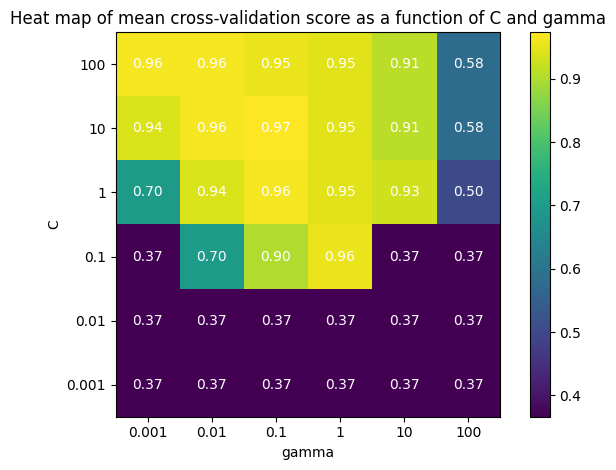

In [16]:
results = grid_search.cv_results_['mean_test_score'].reshape(6,6)[::-1,::]

fig, ax = plt.subplots()
im = ax.imshow(results)

ax.set_xticks(range(len(param_grid['gamma'])), labels=param_grid['gamma'])
ax.set_yticks(range(len(param_grid['C'])), labels=param_grid['C'][::-1])

for i in range(len(param_grid['C'])):
    for j in range(len(param_grid['gamma'])):
        text = ax.text(j, i, '{:.2f}'.format(results[i,j]),
                      ha='center', va='center', color='w')

ax.set_title('Heat map of mean cross-validation score as a function of C and gamma')
ax.set_xlabel('gamma')
ax.set_ylabel('C')
fig.tight_layout()
plt.colorbar(im)
plt.show()

From the heatmap, we can make the following observations:
- The parameters `C` and `gamma` are "important" parameters for the `SVC` estimator, as a step change in them can lead to a high change in the score (40% to 90%).
- We chose an ideal range of the parameters as it contains the optimum test score (the highest score is not at the edge of the grid)

#### Search over spaces that are not grids

The hyperparameters are not always paired when building the estimator.

For instance, the hyperparameter `gamma` will not be used when the hyperparameter `kernel` is `linear`. But, `GridSearchCV` will still add the pairing `SVC(kernel='linear', gamma)` in the grid, even though the value of `gamma` is ignored. So, it would save more time if we only pass the hyperparameters that are paired together.

We can do this in `GridSearchCV` by defining the parameter grid as a list of dictionaries.

In [17]:
param_grid = [
    {
        'kernel':['rbf'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'kernel':['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

grid_search = GridSearchCV(SVC(), param_grid)

X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

grid_search.fit(X_train, y_train)
print('Best parameter:', grid_search.best_params_)
print('Best validation score: {:.2f}'.format(grid_search.best_score_))

Best parameter: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best validation score: 0.97


We can check the cross validation results to see that the value `linear` for the `kernel` is not paired with the values for `gamma`, and is only used when the values of `kernel` is `rbf`. 

In [18]:
pd.DataFrame(grid_search.cv_results_).T

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
mean_fit_time,0.000463,0.00031,0.000306,0.000326,0.000308,0.000333,0.0003,0.000309,0.000303,0.000303,...,0.000242,0.000277,0.00035,0.000357,0.000292,0.000272,0.000249,0.000244,0.000242,0.000248
std_fit_time,0.000113,0.000004,0.000002,0.000029,0.000003,0.000012,0.000002,0.000006,0.000004,0.000002,...,0.000003,0.000006,0.000004,0.000009,0.000006,0.000004,0.000002,0.000002,0.000006,0.000009
mean_score_time,0.000307,0.000193,0.000195,0.000199,0.000193,0.000211,0.00019,0.000194,0.000193,0.000191,...,0.000158,0.000166,0.000184,0.000192,0.000163,0.000163,0.000157,0.000155,0.000154,0.000154
std_score_time,0.00018,0.000003,0.000004,0.000009,0.000002,0.000023,0.000001,0.000005,0.000002,0.000002,...,0.000001,0.000001,0.000002,0.000003,0.000001,0.000001,0.000001,0.000002,0.000002,0.000002
param_C,0.001,0.001,0.001,0.001,0.001,0.001,0.01,0.01,0.01,0.01,...,100.0,100.0,100.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0
param_gamma,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,...,0.1,1.0,10.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN
param_kernel,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,...,rbf,rbf,rbf,rbf,linear,linear,linear,linear,linear,linear
params,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}",...,"{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 10, 'kernel': 'rbf'}","{'C': 100, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.001, 'kernel': 'linear'}","{'C': 0.01, 'kernel': 'linear'}","{'C': 0.1, 'kernel': 'linear'}","{'C': 1, 'kernel': 'linear'}","{'C': 10, 'kernel': 'linear'}","{'C': 100, 'kernel': 'linear'}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,...,1.0,0.956522,0.869565,0.521739,0.347826,0.869565,1.0,1.0,1.0,0.956522
split1_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,...,0.956522,0.956522,0.913043,0.521739,0.347826,0.869565,0.913043,0.956522,1.0,0.956522


#### Using different cross-validation strategies with grid search

We can pass different cross-validation strategies like `ShuffleFold` or `StratifiedGroupFold` to `GridSearchCV`. By default, it used the `StratifiedKFold` strategy.

#### Nested Cross-Validation

In the previous examples, we split the data once into a training & validation set, and a test set. We then fit `GridSearchCV` on the training and validation data to obtain the `SVC` model with the best parameters and best validation score. Finally, we evaluated the model on the test set that is not used in the grid search with cross-validation.

One issue with this one is we would be relying too much on the one-time split of the data before `GridSearchCV`. A better way to evaluate how well the model generalizes on the data is to have an outer loop of cross-validation. This is called **nested cross-validaiton**.

In the outer loop, we have a series of splits of the whole dataset into `trainval` and `test` set. Within each iteration, a grid search with cross validation is done on the `trainval` set, which will be the inner loop for the current iteration.

The result of the nested cross-validation is the best validation score of each grid search within each iteration -- not a model. Hence, this is rarely used when building a model for predicting new data.

However, nested cross-validation sets an upper limit for the generalization performance of a given model.

In [19]:
param_grid = [
    {
        'kernel':['rbf'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'kernel':['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

X = iris.data
y = iris.target

scores = cross_val_score(
    GridSearchCV(SVC(), param_grid),
    X, y
)

print('Cross-validation scores: {}'.format(scores))
print('Mean cross-validation score: {:.2f}'.format(scores.mean()))

Cross-validation scores: [0.96666667 1.         0.9        0.96666667 1.        ]
Mean cross-validation score: 0.97


The result can be summarized as "SVC can achieve 97% mean cross-validation accuracy on the irid dataset" -- nothing more and nothing less.

#### Parallelizing cross-validation and grid search

Each iteration of cross-validation, and each model built in a grid-search can be run in parallel because it is independent of the others.

We can make use of multiple cores in `GridSearchCV` and `cross_val_score` by setting `n_jobs` to the number of CPU cores we want to use.

However, `scikit-learn` does not allow nesting of parallel operations!

In [20]:
import os
import joblib

print('Total cores available:', os.cpu_count())
print('Cores available to joblib:', joblib.cpu_count())

Total cores available: 10
Cores available to joblib: 10


My machine has 10 CPU cores. So, I can set `n_jobs` up to 10.

In [21]:
import time

param_grid = [
    {
        'kernel':['rbf'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'kernel':['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

X = iris.data
y = iris.target

In [22]:
start_time_1 = time.perf_counter()
scores = cross_val_score(
    GridSearchCV(SVC(), param_grid),
    X, y, n_jobs=1
)
end_time_1 = time.perf_counter()

execution_time = end_time_1 - start_time_1
print('Execution time (1 CPU): {:.3f} seconds'.format(execution_time))

Execution time (1 CPU): 0.594 seconds


In [23]:
start_time_2 = time.perf_counter()
scores = cross_val_score(
    GridSearchCV(SVC(), param_grid),
    X, y, n_jobs=10
)
end_time_2 = time.perf_counter()

execution_time_1 = end_time_2 - start_time_2
print('Execution time (10 CPUs): {:.3f} seconds'.format(execution_time_1))

Execution time (10 CPUs): 1.156 seconds


## Evaluation Metrics and Scoring

So far, our method for evluating supervised models are...
- For classification models: Accuracy score (fraction of correctly classified samples)
- For regression models: Coefficient of determination $R^2$

The section will provide other metrics for evaluation; ones that may be more appropriate for the application in mind.

### Keep the End Goal in Mind

In selecting a metric, one of the main considerations is the high-level goal of the application, often called the **business metric**. Examples are the following:
- Avoiding traffic accidents
- Improving pedestrian avoidance capabilities of a self-driving car
- Decreasing the number of hospital admissions
- Getting more users for the website
- Having users spend more money in the shop

The result of choosing a particular algorithm is called the **business impact**.

It is difficult to select the best model -- one with the greatest impact -- because often assessing the business impact of a model might require putting it in production in a real-life system.

Testing a model on a real-life system isn't feasible either! It is often associated with high business or personal risks.

Therefore, we often need to find a **surrogate evaluation procedure**, using a metric that is easier to compute. As much as possible, we want a metric that is closest to the business goal and is feasible to evaluate.

#### Topics to discuss:
- Metrics for binary classification
- Metrics for multiclass classification
- Metrics for regression

### Metrics for Binary Classification

The two classes in binary classification are often called the **positive class** and the **negative class**. The positive class is the class we are interested in.

#### Kinds of errors

Often, accuracy is not a good measure of predictive performance because the proportion of wrong predictions is not the information we need. There are two kinds of mistakes:

1. **False positive (a.k.a. Type I error).** This is when the model predicted a negative sample as positive.
2. **False negative (a.k.a. Type II error).** This is when the prediction is negative when it is actually positive.

These are information not provided by accuracy! And, depending on our application, we might need them to improve the model. More importantly, we always have to know the consequences of making these kinds of errors.

**Example**. Consider an application to screen for the early detection of cancer using an automated test. The positive class is for all samples that got positive in the test; while the negative class is all patients that got a negative.

For a false positive, the patient will undergo further testing. So, the consequences would be the additional cost and inconvenience for the patient.

For a false negative, a sick patient will be classified as negative and will not receive further testing and treatment. This could result in serious health issues, and could even be fatal. So, this is a worse kind of mistake!

In this case, we cannot simply use accuracy to evaluate the model. It may be more effective to use an evaluation strategy that provides false positives and false negatives separately. In particular, we may want to know the false negatives and to minimize false them as much as possible.

#### Imbalanced Datasets

Kinds of errors play a key role on datasets where one class is more frequent than the other. These are called **imbalanced datasets.**

In reality, imbalanced data is the norm, and you would rarely encounter one that have equal or similar frequency in the data.

##### **Example.** *(Click-through prediction)*
In this example, each data point is an "impression": An ad, a related story, or a related person in a social media platform. The goal is to predict whether a user will click on this impression.

A click is rare in the real world; you might need to show a user 100 ads before something gets clicked. This results in an imbalanced dataset where for each 99 "no-click" samples there is 1 "click" sample.

Suppose we built a classifier that has a 99% accuracy. Given that the dataset is imbalanced, it is likely that it has such accuracy because it has correctly predicted 99% no click.

It might have incorrectly predicted all "click" test samples, but those mistakes carried little weight because the click class is only 1% of the data.

##### **Example.** *(Digits dataset)*
Here we will consider two classes: (1) digits that are labelled as 9, and (2) digits that are not 9.

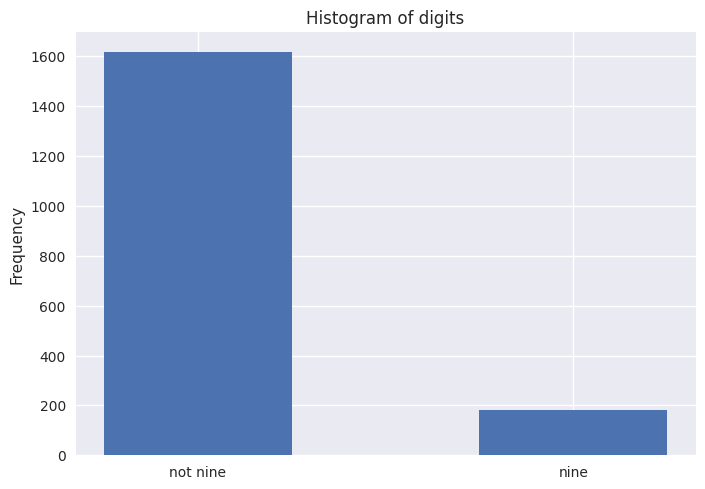

In [24]:
from sklearn.datasets import load_digits

digits = load_digits()
y = digits.target == 9
X = digits.data

with plt.style.context('seaborn-v0_8'):
    plt.hist(y.astype(int), bins=[-0.25,0.25,0.75,1.25])
    plt.xticks([0,1], labels=['not nine','nine'])
    plt.ylabel('Frequency')
    plt.title('Histogram of digits');

In [25]:
from sklearn.dummy import DummyClassifier
most_frequent_dummy = DummyClassifier(strategy='most_frequent')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

most_frequent_dummy.fit(X_train,y_train)
ypred = most_frequent_dummy.predict(X_test)
score = most_frequent_dummy.score(X_test,y_test)

print('Unique predicted labels: {}'.format(np.unique(ypred)))
print('Test score: {:.2f}'.format(score))

Unique predicted labels: [False]
Test score: 0.90


Given the imbalanced dataset, even if we predict 'not nine' all the time, we will still get a 90% accuracy.

In [26]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=2).fit(X_train, y_train)
print('Test score: {:.2f}'.format(tree.score(X_test,y_test)))

Test score: 0.92


Now, an actual classifier is 92% accurate, only slightly better than just saying 'nine' all the time.

For comparison purposes, let's try another dummy model -- one that predicts at random -- and an actual model, the logistic regression model.

In [27]:
from sklearn.linear_model import LogisticRegression

dummy_random = DummyClassifier(strategy='stratified', random_state=1).fit(X_train, y_train)
logreg = LogisticRegression(C=0.1, max_iter=200).fit(X_train, y_train)

print('dummy score: {:.2f}'.format(dummy_random.score(X_test,y_test)))
print('logreg score: {:.2f}'.format(logreg.score(X_test,y_test)))

dummy score: 0.81
logreg score: 0.98


The classifier that predicts a random label is clearly the worst of the lot, but 81% is still good accuracy.

Can we say that the dummy classifiers predict good based on accuracy alone? Clearly not!

The problem is that accuracy is not a good measure of predictive performance on imbalanced datasets; any model could have a high enough accuracy even if it wrongfully predicts all of the least frequent class.

In particular, we need a metric that contains information about false positives and false negatives.

#### Confusion matrices

We can check which samples are correctly classified and wrongfully classified in a matrix with rows corresponding to the actual label and columns corresponding to the model's predicted label. This is called a **confusion matrix**

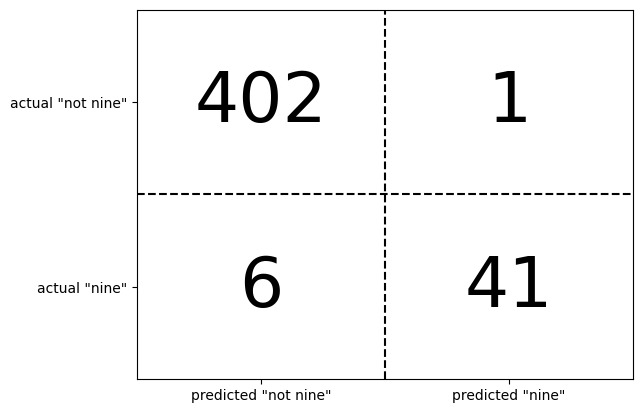

In [28]:
# Confusion matrix for the logistic regression model
from sklearn.metrics import confusion_matrix

# Create a sample confusion matrix plotter for binary classification
def binary_confusion_plot(binary_confusion_matrix, positive_class, negative_class, ax=None):
    if ax is None:
        ax = plt.gca()
    
    for i in range(binary_confusion_matrix.shape[0]):
        for j in range(binary_confusion_matrix.shape[1]):
            ax.text(j, i, '{}'.format(binary_confusion_matrix[::-1][i,j]),
                   ha='center', va='center', fontsize=50)
    
    ax.vlines(x=0.5, ymin=-0.5, ymax=1.5, linestyle='--', colors='k')
    ax.plot([-0.5,1.5], [0.5,0.5], linestyle='--', c='k')
    ax.set_xticks([0,1], labels=[f'predicted "{negative_class}"', f'predicted "{positive_class}"'])
    ax.set_xlim(-0.5,1.5)
    ax.set_yticks([0,1], labels=[f'actual "{positive_class}"', f'actual "{negative_class}"'])
    ax.set_ylim(-0.5,1.5)

confusion = confusion_matrix(y_test, logreg.predict(X_test))

binary_confusion_plot(confusion, 'nine', 'not nine')

Entries on the main diagonal correspond to correct classifications, while the other entries tell us how many samples of one class got incorrectly classified as another class.

If we think of the positive class as the "nine" class and the negative class as "not nine" class, then the confusion matrix tells us the count of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN)!
- There are 402 true negatives since 402 negative samples were correctly classified as positive.
- There are 41 true positives since 41 positive samples were correctly classified as positive.
- There is 1 false positive since 1 negative sample was incorrectly classified as positive.
- There are 6 false negatives since 6 positive samples were incorrectly classified as negative. 

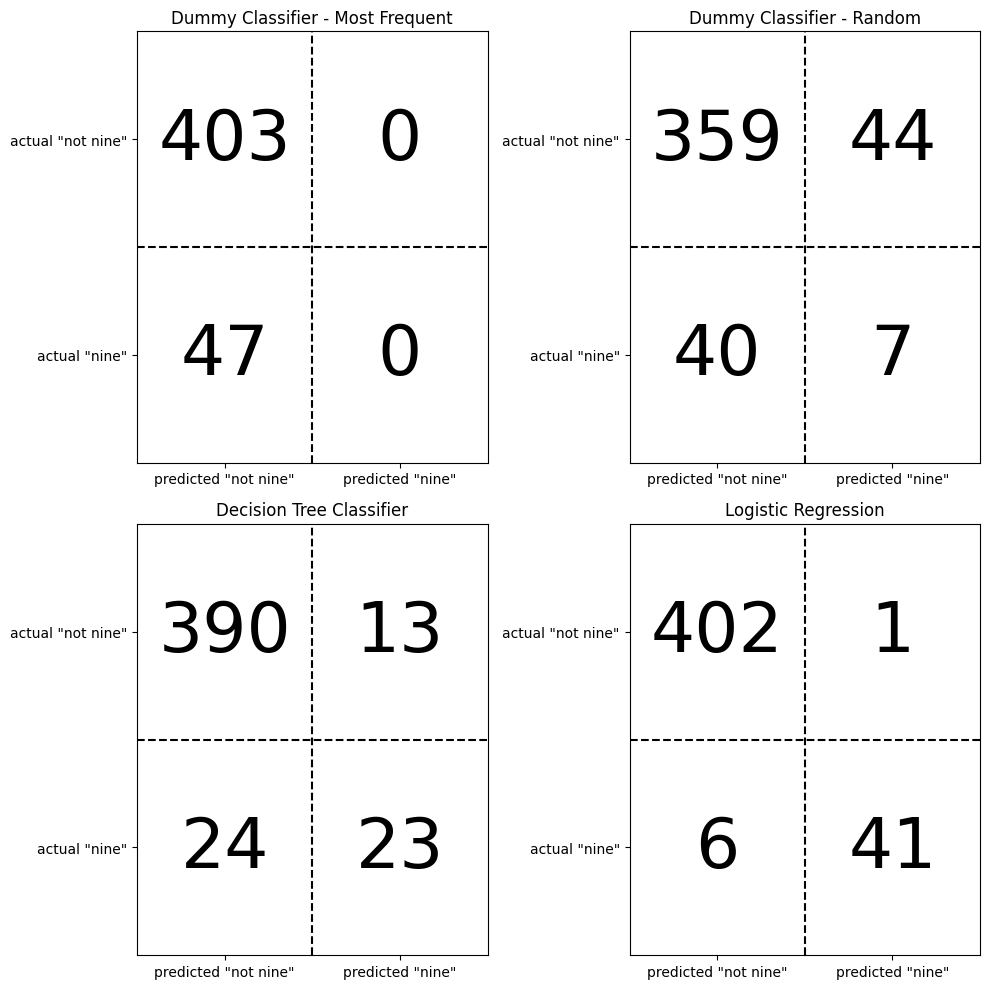

In [29]:
model_list = ['Dummy Classifier - Most Frequent', 'Dummy Classifier - Random', 'Decision Tree Classifier', 'Logistic Regression']
prediction_list = [most_frequent_dummy.predict(X_test),
                  dummy_random.predict(X_test),
                  tree.predict(X_test),
                  logreg.predict(X_test)]

fig, axs = plt.subplots(2,2,figsize=(10,10))
for i, ax in enumerate(axs.flat):
    binary_confusion_plot(
        confusion_matrix(y_test, prediction_list[i]),
        positive_class = 'nine',
        negative_class = 'not nine',
        ax = ax
    )
    ax.set_title(model_list[i])

fig.tight_layout()

We can now see what is wrong with the dummy classifiers, and thus distinguish good predictive modelling from just picking the most frequent class, or just random picking, by individually inspecting the number of true positives and true negatives.

- The "most frequent" dummy classifier, by nature, classified all samples as "not nine". This resulted in 0 true positives and the maximum number of false positive.
- The random classifier also had high counts of false positives and false negatives, with only 7 true positives.
- Both real classifiers (Decision tree and logistic regression) have lower false positives and false negatives.

This method of evaluation is particularly effective for imbalanced datasets; more effective than simply checking the accuracy. As we saw earlier, the dummy classifiers had high accuracy because the most frequent class out-weighed the other class. With confusion matrices, we are able to see how bad the dummy classifiers were by individually checking the number of true positives and true negatives.

##### **Summarizing information in the confusion matrix**
While we gained a lot of insight from inspecting the entries of the confusion matrix, the process was very manual and qualitative. It would be better if we can summarize the information provided by the confusion matrix. And there are several ways to do that!

Generally speaking, the confusion matrix provides the count of true positives, true negatives, false positives, and false negatives.

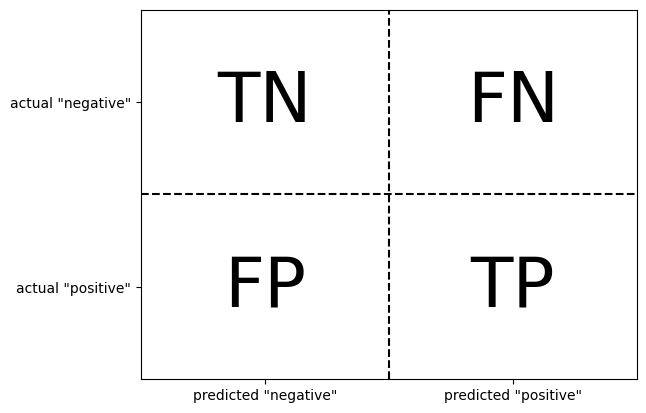

In [30]:
confusion = np.array([['TN', 'FN'],['FP', 'TP']])
binary_confusion_plot(confusion, 'positive', 'negative')

**Relation to accuracy.** One way to summarize the confusion matrix is the accuracy itself. It is the total number of correct predictions, $\text{TN}+\text{TP}$, divided by the total number of samples, $\text{TN}+\text{TP}+\text{FN}+\text{FP}$

$$\text{Accuracy} = \frac{\text{TN}+\text{TP}}{\text{TN}+\text{TP}+\text{FN}+\text{FP}}$$

**Precision, recall, and f-score.** There are several ways of summarizing the confusion matrix into one number other than accuracy, and they may be more suitable for the end goal.

*Precision* is the number of positive predictions that are actually positive.

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

Precision is a performance metric when the goal is to limit the number of false positives. Precision is also known as **positive predictive value (PPV)**

*Recall* measures how many of the positive samples are predicted positive.

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

Other names for recall are **sensitivity, hit rate,** or **true positive rate (TPR)**.

There is a trade-off between optimizing precision and optimizing recall. You can build a model that predicts all sampless to belong to the positive class (no false negatives and no true negatives either) and it will have perfect recall, but very low precision. On the other hand, you can also build one that predicts only those samples it is sure about as positive, and the rest as negative. In that case, false positives are minimized, but there will be a lot of false negatives. It will have high precision, but low recall.

So, looking at only one of the two measures does not provide us a full picture. One way to summarize them is the **$f$-score** or **$f$-measure**, which is the harmonic mean of precision and recall.

$$f = 2\cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

This particular variant of the $f$-score is called the $f_1$-score

In [31]:
from sklearn.metrics import f1_score

for i, predict in enumerate(prediction_list):
    print('f1 score {}: {:.2f}'.format(model_list[i], f1_score(y_test, predict)))

f1 score Dummy Classifier - Most Frequent: 0.00
f1 score Dummy Classifier - Random: 0.14
f1 score Decision Tree Classifier: 0.55
f1 score Logistic Regression: 0.92


With the $f_1$-score, there is a good distinction between the dummies and the real classifiers. Furthermore, the $f_1$-score has summarized predictive performance with only a single number, same as accuracy. However, it summarizes information that accuracy does not provide.

One disadvantage of $f_1$-score is it is harder to interpret and explain than accuracy.

If we want a more comprehensive summary of precision, recall, and $f_1$-score, we can use Scikit-learn's `classification_report` convenience function.

In [32]:
from sklearn.metrics import classification_report

for i, predict in enumerate(prediction_list):
    print('Classification Report: {}\n {}'.format(model_list[i], classification_report(y_test, 
                                                                                       predict, 
                                                                                       target_names=['not nine', 'nine'],
                                                                                       zero_division=0.0)
                                                 )
         )

Classification Report: Dummy Classifier - Most Frequent
               precision    recall  f1-score   support

    not nine       0.90      1.00      0.94       403
        nine       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450

Classification Report: Dummy Classifier - Random
               precision    recall  f1-score   support

    not nine       0.90      0.89      0.90       403
        nine       0.14      0.15      0.14        47

    accuracy                           0.81       450
   macro avg       0.52      0.52      0.52       450
weighted avg       0.82      0.81      0.82       450

Classification Report: Decision Tree Classifier
               precision    recall  f1-score   support

    not nine       0.94      0.97      0.95       403
        nine       0.64      0.49      0.55        47

    accuracy              

From the classification report, we can see the superiority of the logistic regression. Having high accuracy, and a significantly higher precision than the other models with 'nine' class as the positive class.

#### Taking uncertainty into account

The confusion matrix provides a way to analyze a particular set of predictions. But calling the predictions threw away a lot information as the model knows more than that. The predictions do not contain the model's certainty of each sample -- whether a sample is of class 1 or class 0. That information is contained in the model's decision function or predicted probabilities.

We can think of making predictions as imposing a threshold on the decision function.

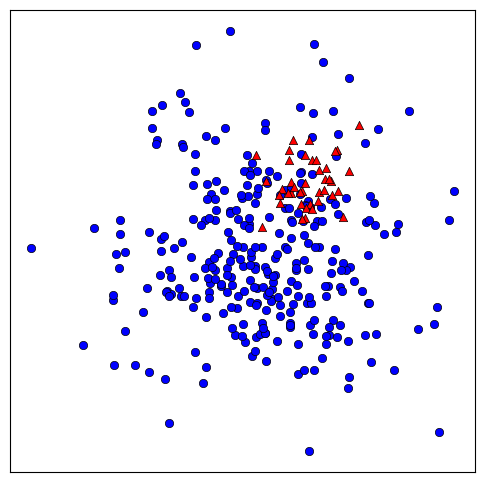

In [37]:
from sklearn.datasets import make_blobs

# Generate random data
X, y = make_blobs(n_samples=(400,50), cluster_std=[7.0,2], random_state=22)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

fig, axs = plt.subplots(1,1,figsize=(6,6),
                       subplot_kw=dict(xticks=[], yticks=[]))

axs.scatter(X_train[y_train < 1][:,0], X_train[y_train < 1][:,1], c='blue', ec='k', lw=0.5)
axs.scatter(X_train[y_train > 0][:,0], X_train[y_train > 0][:,1], c='red', marker='^', ec='k', lw=0.5);

Here we are dealing with an imbalanced data -- 400 from the negative class and 50 from the positive class. We will train a SVC classifier with radial basis function as kernel and `gamma=0.05`

In [38]:
from sklearn.svm import SVC
svc = SVC(gamma=.05).fit(X_train,y_train)

Next, we will plot the classifier's decision function.

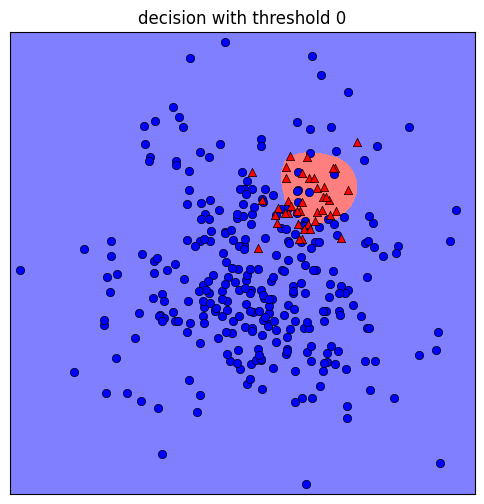

In [94]:
def plot_clf_predictions(clf, X, threshold = 0, ax=None, mesh_size=500):
    '''
    Plot a classifier's predictions based on its decision function
    and a threshold

    clf: fitted classifier
    X: feature matrix
    threshold: float to threshold the decision function; default 0
    '''
    if ax is None:
        ax = plt.gca()
        
    ax.set_xlim(X[:,0].min()-1,X[:,0].max()+1)
    ax.set_ylim(X[:,1].min()-1,X[:,1].max()+1)
    
    xx, yy = np.meshgrid(np.linspace(*ax.get_xlim(), mesh_size),
                        np.linspace(*ax.get_ylim(), mesh_size))
    grid = np.column_stack([xx.ravel(),yy.ravel()])
    ypred = clf.decision_function(grid) > threshold
    ax.pcolormesh(xx, yy, ypred.reshape(xx.shape), alpha=0.5, cmap='bwr')

fig, axs = plt.subplots(1,1,figsize=(6,6),
                       subplot_kw=dict(xticks=[], yticks=[]))

plot_clf_predictions(svc, X, threshold = 0, ax=axs)
axs.scatter(X_train[y_train < 1][:,0], X_train[y_train < 1][:,1], c='blue', ec='k', lw=0.5)
axs.scatter(X_train[y_train > 0][:,0], X_train[y_train > 0][:,1], c='red', marker='^', ec='k', lw=0.5)
axs.set_title('decision with threshold 0');

The decision function provides a score for each sample, a score that indicates the model's certainty of which class the model belongs to. A more negative score indicates that the model is sure it is a negative class, and a more positive score indicates that the model is sure it is a positive class.

Imposing a threshold on the decision function means providing a distinction on which is positive or negative based on the scores.
- If the sample's score is higher than the threshold, it is positive class
- If the sample's score is lower than the threshold, it is negative class.

By default, the `predict()` method imposes a threshold value of 0 on the decision function and outputs the resulting class of each sample based on their scores and the threshold. Samples with negative scores will be labelled negative; if their scores are positive, they are labelled positive class.

Let's look at the classification report of the SVC for the prediction, with a default threshold of 0.

In [98]:
ypred = svc.decision_function(X_test) > 0 #This is the same as calling svc.predict()
print('SVC Prediction (decision with threshold 0) \n {}'.format(classification_report(y_test, ypred)))

SVC Prediction (decision with threshold 0) 
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       104
           1       0.35      0.67      0.46         9

    accuracy                           0.88       113
   macro avg       0.66      0.78      0.70       113
weighted avg       0.92      0.88      0.89       113



For the positive class, we get a fairly small recall. This means that the model predicted many false negatives and only a small number of true positives. Furthermore, we get a poor precision for the positive class, indicating that there were more false positives than true positives.

On the other hand, the model had good recall and precision on the negative class. This is typical of modeling imbalanced data -- the classifier focuses more on predicting the most frequent class.

We can verify the results of the classification report in the confusion matrix.

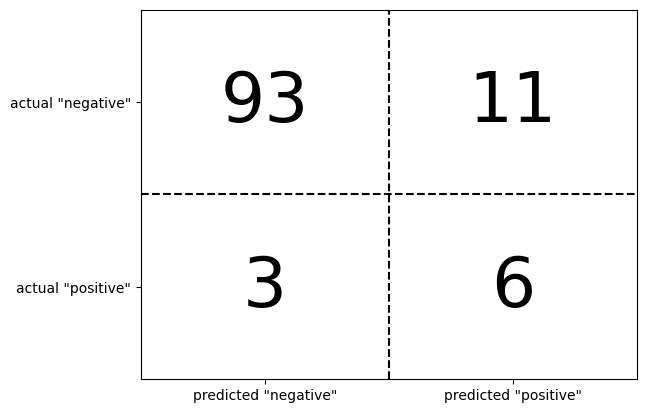

In [100]:
confusion = confusion_matrix(y_test, ypred)
binary_confusion_plot(confusion, 'positive', 'negative')

Recall was fairly low because 1/3 of the positive class were predicted as negative. And precision was very low because there were more false positives than true positives.

Now, suppose that our application calls for a model with higher recall. This means we are willing to sacrifice getting more false positives in exchange for more true positives and less false negatives.

Our current threshold of 0 does not fulfill this requirement, but we can adjust the threshold from 0. In our case, we can decrease the threshold, say to -0.8, so that we get a broader area for the positive class.

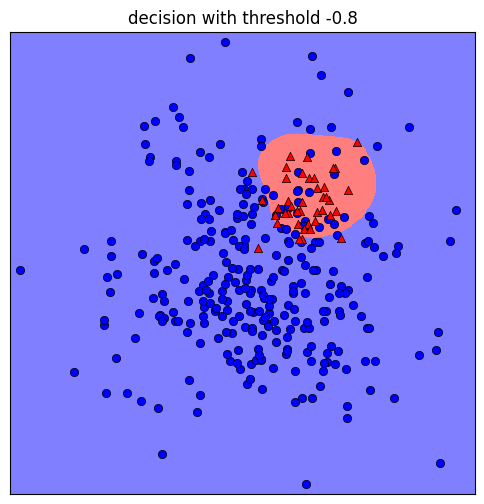

In [101]:
fig, axs = plt.subplots(1,1,figsize=(6,6),
                       subplot_kw=dict(xticks=[], yticks=[]))

plot_clf_predictions(svc, X, threshold = -0.8, ax=axs)
axs.scatter(X_train[y_train < 1][:,0], X_train[y_train < 1][:,1], c='blue', ec='k', lw=0.5)
axs.scatter(X_train[y_train > 0][:,0], X_train[y_train > 0][:,1], c='red', marker='^', ec='k', lw=0.5)
axs.set_title('decision with threshold -0.8');

As expected. By decreasing the threshold to -0.8, the area for the positive class became broader.

In [104]:
ypred = svc.decision_function(X_test) > -0.8 #This is the same as calling svc.predict()
print('SVC Prediction (decision with threshold -0.8) \n {}'.format(classification_report(y_test, ypred)))

SVC Prediction (decision with threshold -0.8) 
               precision    recall  f1-score   support

           0       1.00      0.82      0.90       104
           1       0.32      1.00      0.49         9

    accuracy                           0.83       113
   macro avg       0.66      0.91      0.69       113
weighted avg       0.95      0.83      0.87       113



And as we can see, the model had the highest recall for the positive class. However, the precision became smaller. That is because we sacrificed getting more false positives.

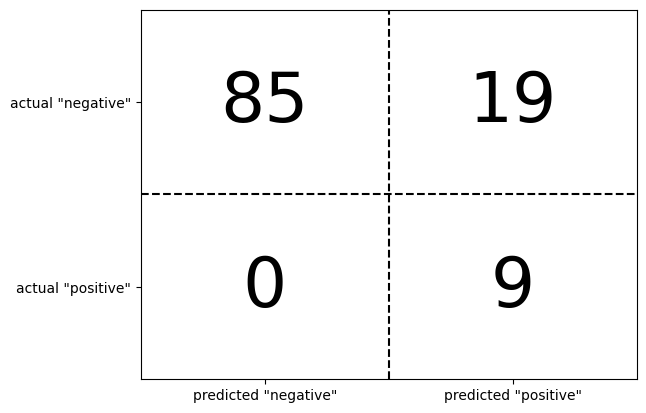

In [103]:
confusion = confusion_matrix(y_test, ypred)
binary_confusion_plot(confusion, 'positive', 'negative')

We got 0 false negatives. That is why the recall was very high! If we prioritize precision over recall, then we would just do it the other way around--by imposing a stricter threshold.

SVC Prediction (decision with threshold 1.09) 
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       104
           1       1.00      0.11      0.20         9

    accuracy                           0.93       113
   macro avg       0.96      0.56      0.58       113
weighted avg       0.93      0.93      0.90       113



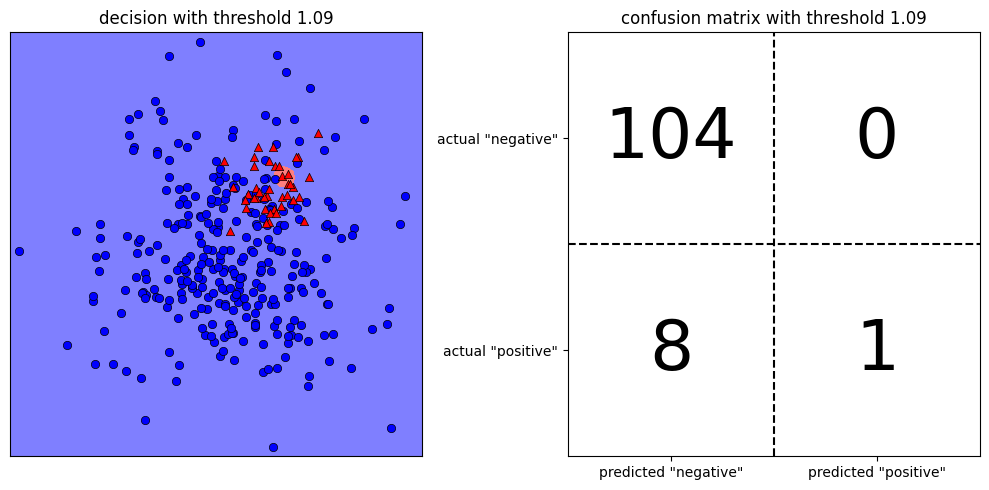

In [140]:
fig, axs = plt.subplots(1,2,figsize=(10,5),subplot_kw=dict(xticks=[], yticks=[]))
threshold = 1.09
ypred = svc.decision_function(X_test) > threshold

print('SVC Prediction (decision with threshold {}) \n {}'.format(threshold, classification_report(y_test, ypred)))

plot_clf_predictions(svc, X, threshold, ax=axs[0])
axs[0].scatter(X_train[y_train < 1][:,0], X_train[y_train < 1][:,1], c='blue', ec='k', lw=0.5)
axs[0].scatter(X_train[y_train > 0][:,0], X_train[y_train > 0][:,1], c='red', marker='^', ec='k', lw=0.5)
axs[0].set_title('decision with threshold {}'.format(threshold))

confusion = confusion_matrix(y_test,ypred)
binary_confusion_plot(confusion, 'positive', 'negative', ax=axs[1])
axs[1].set_title('confusion matrix with threshold {}'.format(threshold))
fig.tight_layout();

#### Precision-recall curves and ROC curves

We set a particular value for recall or precision -- say, 90% recall -- based on our application. Once we set such value, we can adjust the threshold appropriately. And it is always possible for any target value. The hard part is managing the trade-off between precision and recall -- we could adjust the threshold to get 90% recall, but if the precision becomes very low, then the model would be useless.

Setting a requirement on a classifier like 90% recall is often called setting the **operating point**.

To be able to look at all possible trade-offs between precision and recall at various thresholds at once, we can plot a parametric curve with precision as a function of threshold as the first coordinate, and recall as a function of threshold as the second coordinate. This is called a **precision-recall curve**.

$$\text{Precision Recall Curve} := \left(\,\text{precision}(t),\, \text{recall}(t)\,\right)$$
$$t := \text{threshold}$$

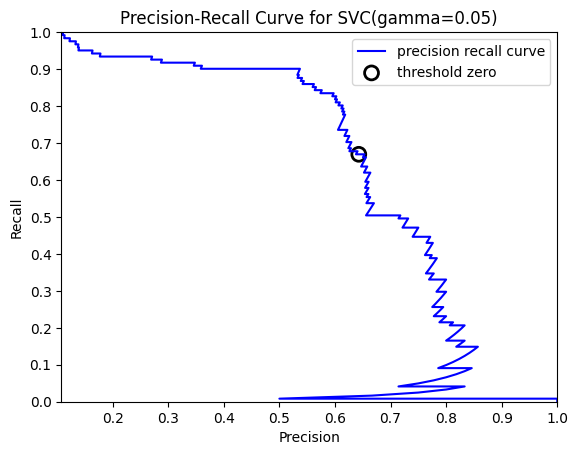

In [283]:
from sklearn.metrics import precision_recall_curve

svc = SVC(gamma=.05)

X, y = make_blobs(n_samples=(4000, 500), cluster_std=[7.0,2], random_state=22)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

svc.fit(X_train, y_train)

y_score = svc.decision_function(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Get index of threshold closest to zero
def closest_zero(thresholds):
    pmask = thresholds >= 0
    nmask = thresholds < 0
    psmallest = thresholds[pmask].min()
    nlargest = thresholds[nmask].max()
    if abs(psmallest) < abs(nlargest):
        closest = np.where(thresholds == psmallest)[0][0]
    else:
        closest = np.where(thresholds == nlargest)[0][0]
        
    return closest

closest = closest_zero(thresholds) #index of the threshold closest to zero
plt.plot(precision,recall, c='blue', label='precision recall curve')
plt.scatter(precision[closest], recall[closest], marker='o', s=100, label='threshold zero', facecolors='none', ec='k', lw=2)

plt.xticks(np.linspace(0,1,11))
plt.yticks(np.linspace(0,1,11))
plt.xlim(precision.min(),precision.max())
plt.ylim(recall.min(),recall.max())
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Precision-Recall Curve for SVC(gamma=0.05)')
plt.legend()

plt.show()

The precision-recall curve shows the different operating points of the SVC model. The closer the curve stays at the upper right corner of the plot, the better the classifier as it corresponds to high precision and high recall.

We can also see from the curve that if we want a higher precision, we would be sacrificing a lot of recall because at 50% precision and up, the recall quickly decreases.

Let's try to compare our current model's operating curve with a random forest classifier.

Now, the random forest classifier does not have a decision function. The `predict_proba` is the model's way of scoring the samples -- with probability estimates.

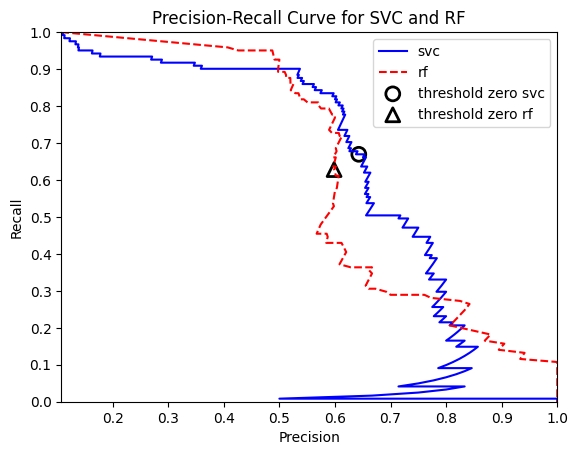

In [224]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state=0, max_features=2)
rf.fit(X_train, y_train)

# The predict_proba methods returns an array of shape (n_samples, n_classes)
# Each column corresponds to a class and contains the probabilities of the samples to belong to the corresponding class
# In this case, Column 0 contains probabilities that the samples belong to the 0 class (or negative class)
# Column 1 contains probabilities of belonging to class 1 (positive class)
y_score_rf = rf.predict_proba(X_test)[:,1] 

precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_score_rf)
closest_rf = np.argmin(np.abs(thresholds_rf-0.5))

plt.plot(precision,recall, c='blue', label='svc')
plt.plot(precision_rf, recall_rf, c='red', ls='--', label='rf')
plt.scatter(precision[closest], recall[closest], marker='o', s=100, label='threshold zero svc', facecolors='none', ec='k', lw=2)
plt.scatter(precision_rf[closest_rf], recall_rf[closest_rf], marker='^', s=100, label='threshold zero rf', facecolors='none', ec='k', lw=2)

plt.xticks(np.linspace(0,1,11))
plt.yticks(np.linspace(0,1,11))
plt.xlim(min(precision.min(),precision_rf.min()),
         max(precision.max(),precision_rf.max()))
plt.ylim(min(recall.min(),recall_rf.min()),
         max(recall.max(),recall_rf.max()))
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Precision-Recall Curve for SVC and RF')
plt.legend()

plt.show()

Here we can compare the operating curves of the SVC and RF.
- At the default threshold (0 for the SVC, 0.5 for the RF) the support vector classifier performed better as it is closer to the upper right corner. In fact, the SVC is superior in the middle -- between 50% and 80% precision.
- On the other hand, the random forest classifier performs better at extreme precision and recall requirements.

These are details that the f1 score does not contain. The f1 score only provides a summary of one point of the precision-recall curve: That is, at the default threshold.

In [228]:
print("f1_score of random forest: {:.3f}".format(f1_score(y_test, rf.predict(X_test))))
print("f1_score of svc: {:.3f}".format(f1_score(y_test, svc.predict(X_test))))

f1_score of random forest: 0.610
f1_score of svc: 0.656


##### **Summarizing the precision-recall curve**

One way to summarize the precision-recall curve is by computing the average of precision recall curve: That is, finding the area under the precision recall curve and dividing by the length of the range of recall.

$$\text{AP} = \frac{1}{R_{\text{max}} - R_{\text{min}}} \int_{R_{\text{min}}}^{R_{\text{max}}}{P(R)\,dR}$$

Since recall always ranges from 0 to 1, the length of the range of recall $R_{\text{max}} - R_{\text{min}}$ evaluates to 1. So, the AP simplifies to just the area under the curve, which can be expressed as the integral of precision with respect to recall. Numerically, the formula is

$$\text{AP} = \sum_{n}{P_n (R_n - R_{n-1})}$$

In [257]:
from sklearn.metrics import average_precision_score
ap_svc = average_precision_score(y_test, y_score)
ap_rf = average_precision_score(y_test, y_score_rf)

print('Average precision of random forest: {:.3f}'.format(ap_rf))
print('Average precision of svc: {:.3f}'.format(ap_svc))

Average precision of random forest: 0.659
Average precision of svc: 0.666


The average precision tells us how good is the classifier's certainty over all possible recall values. A model with a higher AP is better because it has higher precision over a broader range of recalls.

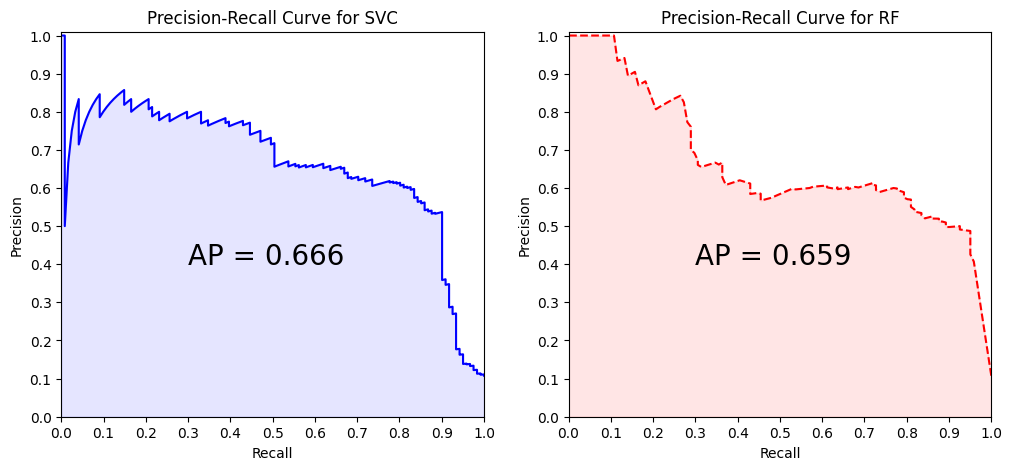

In [263]:
fig,axs = plt.subplots(1,2,figsize=(12,5),
                      subplot_kw = dict(xticks=np.linspace(0,1,11),
                                       yticks=np.linspace(0,1,11),
                                       xlabel='Recall',
                                       ylabel='Precision',
                                       xlim=(0,1),
                                       ylim=(0,1.01)))

axs[0].plot(recall, precision, c='blue', label='svc')
axs[0].fill_between(recall, precision, color='blue', alpha=0.1)
axs[0].set_title('Precision-Recall Curve for SVC')
axs[0].text(0.3,0.4,'AP = {:.3f}'.format(ap_svc),size=20)

axs[1].plot(recall_rf, precision_rf, c='red', ls='--', label='rf')
axs[1].fill_between(recall_rf, precision_rf, color='red', alpha=0.1)
axs[1].set_title('Precision-Recall Curve for RF')
axs[1].text(0.3,0.4,'AP = {:.3f}'.format(ap_rf),size=20)

plt.show()

Here we can see that the SVC model had a higher average precision. This is evident in the plot -- the precision recall curve of the SVC model is better at maintaining a high precision over a broader range of recalls.

#### Receiver operating characteristics (ROC) and AUC

Another way to analyze the behavior of classifiers at different thresholds is the **receiver operating characteristics** curve, or **ROC** curve.

Similar to the precision-recall curve, the ROC curve considers all possible thresholds, but instead of visualizing the trade-off between precision and recall, it represents the trade-off between sensitivity (a.k.a recall) and specificity (tied with its complement, the false positive rate).

$$\text{False Positive Rate (FPR)} = \frac{\text{FP}}{\text{FP} + \text{TN}},\quad \text{Specificity} = 1-\text{FPR}$$

The ROC curve is the plot of the TPR against FPR.

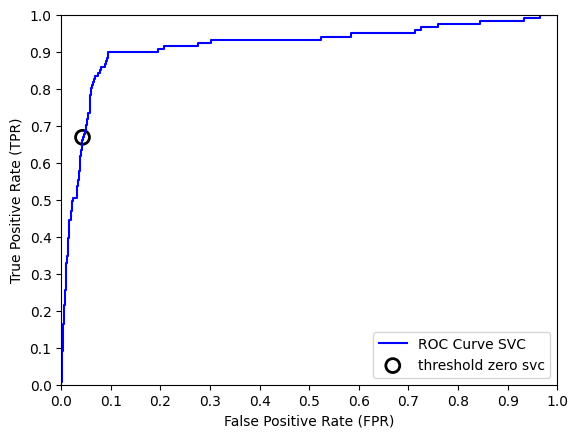

In [285]:
from sklearn.metrics import roc_curve

fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_score)
closest_svc = np.argmin(np.abs(thresholds_svc))

plt.plot(fpr_svc, tpr_svc, c='blue', label='ROC Curve SVC')
plt.scatter(fpr_svc[closest_svc], tpr_svc[closest_svc],
            marker='o', s=100, label='threshold zero svc', facecolors='none', ec='k', lw=2)

plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.linspace(0,1,11))
plt.yticks(np.linspace(0,1,11))
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.show()

- The closer the curve stays at the upper left corner is a better classifier as it has a higher false positive rate and a lower false positive rate.
- As we can see in the above figure, it may be better to consider the operating point closest to the upper left corner than the default threshold.

Let's compare the SVC and RF model again.

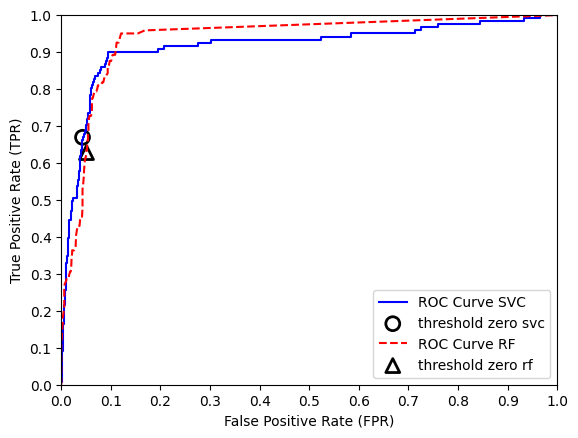

In [286]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_score_rf)
closest_rf = np.argmin(np.abs(thresholds_rf-0.5))

plt.plot(fpr_svc, tpr_svc, c='blue', label='ROC Curve SVC')
plt.scatter(fpr_svc[closest_svc], tpr_svc[closest_svc],
            marker='o', s=100, label='threshold zero svc', facecolors='none', ec='k', lw=2)
plt.plot(fpr_rf, tpr_rf, c='red', ls='--', label='ROC Curve RF')
plt.scatter(fpr_rf[closest_rf], tpr_rf[closest_rf],
            marker='^', s=100, label='threshold zero rf', facecolors='none', ec='k', lw=2)

plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.linspace(0,1,11))
plt.yticks(np.linspace(0,1,11))
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.show()

Here we can see that the SVC performs better than the random forest at lower thresholds. But the random forest exhibits a higher peak of the true positive rate. Perhaps the random forest would be a better classifier if we are willing to sacrifice to predict more false positives in exchange for lower false negatives.

Similar to the PR curve, we can also consider the area under the ROC curve, i.e. the average of the curve, to summarize the ROC curve for a classifier; providing an automatic way to compare models. The area under the ROC curve is often called the **AUC** (and it is understood that the curve is the ROC curve).

In [280]:
from sklearn.metrics import roc_auc_score

auc_svc = roc_auc_score(y_test, y_score)
auc_rf = roc_auc_score(y_test, y_score_rf)

print('ROC AUC for Random Forest: {:.3f}'.format(auc_rf))
print('ROC AUC for SVC: {:.3f}'.format(auc_svc))

ROC AUC for Random Forest: 0.937
ROC AUC for SVC: 0.916


The AUC can be interpreted as evaluating the ranking of positive samples. It is equivalent to the probability that the classifier ranks a randomly chosen positive sample higher than a randomly chosen negative sample.

Thus, an AUC of 1.0 means that the classifier will rank all positive samples higher than all negative samples; while the baseline AUC is 0.5 as it corresponds to a classifier that randomly ranks the samples (like tossing a coin).

**ROC AUC vs. Average Precision**
- The ROC AUC is generally a good metric when the cost of false negatives and false positives are roughly the same or symmetric. It also works well on balanced to moderately balanced datasets.
- On the other hand, the AP is a good metric when the positive class is rare and your interest is identifying positive samples.

### Metrics for Multiclass Classification

Metrics are derived from binary classification.
- Accuracy
- Confusion matrix
- Precision, recall, f1-score

Let's discuss metrics with the digits dataset as an example

Accuracy: 0.953


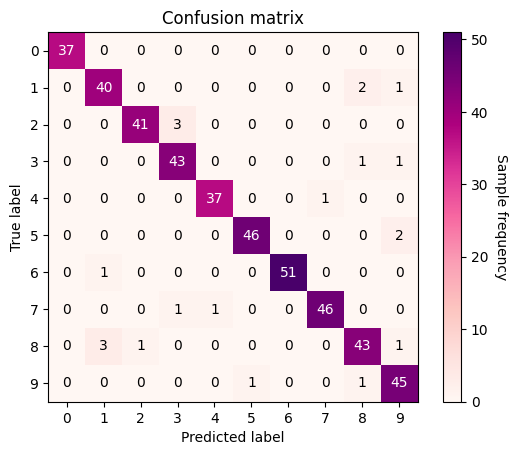

In [304]:
from sklearn.metrics import accuracy_score

# Use the logistic regression model
lr = LogisticRegression(max_iter=150)

# Prepare data
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Fit the model
lr.fit(X_train, y_train)

# Model evaluation - Accuracy
pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('Accuracy: {:.3f}'.format(accuracy))

# Model evaluation - Confusion matrix
cmatrix = confusion_matrix(y_test, pred)

fig,ax = plt.subplots()

# Plot confusion matrix with imshow
im = ax.imshow(cmatrix, cmap='RdPu')
for i in range(len(cmatrix)):
    for j in range(len(cmatrix)):
        ax.text(j, i, cmatrix[i,j],
               color='white' if i==j else 'black', ha='center', va='center')

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Sample frequency', rotation=-90, va='bottom')

# Subplot kw
ax.set_title('Confusion matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks(np.unique(y))
ax.set_yticks(np.unique(y))

plt.show()

- For the digit 0, there are 37 samples, and all were correctly classified. This can be seen in the confusion matrix because all other entries in the first row are 0 (meaning no false negatives). Furthermore, all other entries in the first column are 0 -- meaning that no digits were mistakenly classified as 0 (no false positives).
- For the digit 1, there were two '1' samples that were classified as 8, and one '1' sample classified as 9. Hence, there are a total of 3 false negatives. On the other hand, there were three '8' samples that are classified as 1 and one '6' sample classified as 1. Hence, there are 4 false positives.

In [305]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.91      0.93      0.92        43
           2       0.98      0.93      0.95        44
           3       0.91      0.96      0.93        45
           4       0.97      0.97      0.97        38
           5       0.98      0.96      0.97        48
           6       1.00      0.98      0.99        52
           7       0.98      0.96      0.97        48
           8       0.91      0.90      0.91        48
           9       0.90      0.96      0.93        47

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



For class 6, the precision was 1.0 because there were no false positives as can be seen in the confusion matrix (all other entries in column 6 are zero) but recall was 0.98 because one positive sample was mistakenly classified as a 1 digit.

The multiclass version of the f-score:
1. For each class, a binary $f$-score is computed, with the current class being the positive class, and the other classes being the negatives.
2. The above per-class $f$-scores are then averaged using one of the following strategies.
   - **Macro** averaging computes the unweighted average of the per-class $f$-scores.
   - **Weighted** averaging computed the weighted average of the per-class $f$-scores.
   - **Micro** averaging does not use the per-class $f$-scores. Instead, it computes the total number of false positives, false
     negatives, and true positives, and computes precision, recall, and $f$-score based on those counts.

**Which strategy to use?** If you care about *samples* equally much, use "micro" average $f_1$-score. If you care about *classes* equally much, use "macro" average $f_1$-score.

In [308]:
print('Micro average f1 score: {:.3f}'.format(f1_score(y_test, pred, average='micro')))
print('Macro average f1 score: {:.3f}'.format(f1_score(y_test, pred, average='macro')))

Micro average f1 score: 0.953
Macro average f1 score: 0.954


There wouldn't be any distinction because the data is balanced.

### Regression Metrics
just use $R^2$ bro...

- $R^2$ as a scoring method for all regressors is enough
- But don't forget other methods as well, e.g., MSE and MAE. Sometimes business decisions are made on the basis of these other methods.

### Using Evaluation Metrics in Model Selection

To use the metrics precision, recall, $f_1$-score, Average precision, ROC-AUC in our grid searches or cross-validation, we can simply explicitly set the parameter `scoring` of Scikit-learn's `GridSearchCV` and `cross_val_score`.

Let's use the AUC scoring to evaluate the SVC in the "nine vs. rest" task.

In [312]:
from sklearn.model_selection import cross_val_score

svc = SVC()

X = digits.data
y = digits.target == 9

cv_default = cross_val_score(svc, X, y, cv=3)
cv_accuracy = cross_val_score(svc, X, y, scoring='accuracy', cv=3)
cv_auc = cross_val_score(svc, X, y, scoring='roc_auc', cv=3)

print('Default scoring: {}'.format(np.round(cv_default,3)))
print('Explicit accuracy scoring: {}'.format(np.round(cv_accuracy,3)))
print('AUC scoring: {}'.format(np.round(cv_auc,3)))

Default scoring: [0.98  0.987 0.983]
Explicit accuracy scoring: [0.98  0.987 0.983]
AUC scoring: [0.996 0.999 0.99 ]


Similar to `cross_val_score`, we can also set the `scoring` parameter to the preferred metric in `GridSearchCV`.

In [324]:
from sklearn.model_selection import GridSearchCV

# Grid search using the default scoring method: accuracy
param_grid = {'gamma': [0.0001, 0.01, 0.1, 1, 10]}
grid_default = GridSearchCV(SVC(), param_grid, scoring='accuracy')

# Prepare data
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, random_state=0)

# Fit grid search
grid_default.fit(X_train_val, y_train_val)
best_score_default = grid_default.best_score_
best_params_default = grid_default.best_params_

# Model evaluation
df_default = grid_default.best_estimator_.decision_function(X_test)
auc_default = roc_auc_score(y_test, df_default)
accuracy_default = grid_default.score(X_test, y_test)

print('Grid-Search with accuracy')
print('Best parameters: {}'.format(best_params_default))
print('Best cross-validation score (accuracy): {:.3f}'.format(best_score_default))
print('Test set AUC: {:.3f}'.format(auc_default))
print('Test set accuracy: {:.3f}'.format(accuracy_default))

Grid-Search with accuracy
Best parameters: {'gamma': 0.0001}
Best cross-validation score (accuracy): 0.976
Test set AUC: 0.992
Test set accuracy: 0.973


In [325]:
from sklearn.model_selection import GridSearchCV

# Grid search using the AUC
param_grid = {'gamma': [0.0001, 0.01, 0.1, 1, 10]}
grid_auc = GridSearchCV(SVC(), param_grid, scoring='roc_auc')

# Prepare data
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, random_state=0)

# Fit grid search
grid_auc.fit(X_train_val, y_train_val)
best_score_auc = grid_auc.best_score_
best_params_auc = grid_auc.best_params_

# Model evaluation
df_auc = grid_auc.best_estimator_.decision_function(X_test)
auc_auc = roc_auc_score(y_test, df_auc)
accuracy_auc = grid_auc.score(X_test, y_test)

print('Grid-Search with AUC')
print('Best parameters: {}'.format(best_params_auc))
print('Best cross-validation score (AUC): {:.3f}'.format(best_score_auc))
print('Test set AUC: {:.3f}'.format(auc_auc))
print('Test set accuracy: {:.3f}'.format(accuracy_auc))

Grid-Search with AUC
Best parameters: {'gamma': 0.01}
Best cross-validation score (AUC): 0.998
Test set AUC: 1.000
Test set accuracy: 1.000
